# From Previous Notebook

In [ ]:
 import kagglehub

# Download latest version
path = kagglehub.dataset_download("moazeldsokyx/dogs-vs-cats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogs-vs-cats' dataset.
Path to dataset files: /kaggle/input/dogs-vs-cats


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

In [ ]:
# we will be using generators (form keras) which automatically divides data into batches internally

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogs-vs-cats/dataset/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

val_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogs-vs-cats/dataset/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 12461 files belonging to 2 classes.


In [ ]:
# since the pixels in the image are from 0 to 255, we have to normalize it from 0-1 scale
def process(image,label):
  image= tf.cast(image/255. , tf.float32)
  return image,label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [ ]:
# creating the CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10, validation_data=val_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.6166 - loss: 0.6566 - val_accuracy: 0.7386 - val_loss: 0.5193
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.7629 - loss: 0.4841 - val_accuracy: 0.7950 - val_loss: 0.4450
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.8247 - loss: 0.3879 - val_accuracy: 0.7943 - val_loss: 0.4737
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.8841 - loss: 0.2712 - val_accuracy: 0.7955 - val_loss: 0.5488
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.9378 - loss: 0.1527 - val_accuracy: 0.7834 - val_loss: 0.8092
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.9689 - loss: 0.0878 - val_accuracy: 0.7856 - val_loss: 1.0622
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.9742 - loss: 0.0691 - val_accuracy: 0.7631 - val_loss: 1.0647
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.9804 - loss: 0.0590 -

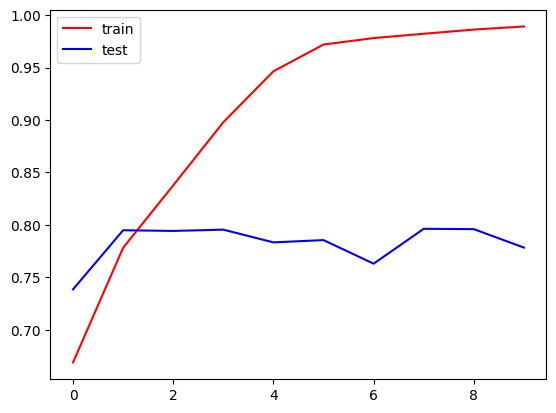

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='test')
plt.legend()
plt.show()

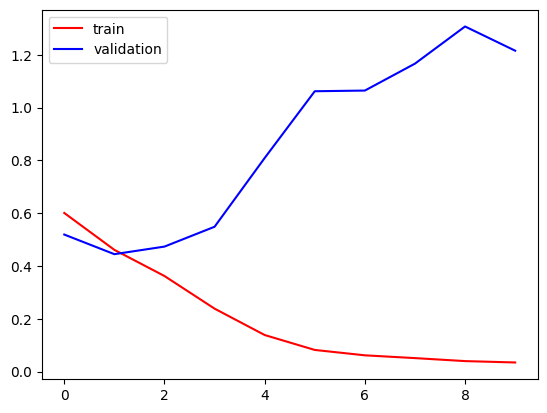

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
# looks like the model is overfitting
# Here's the things that can be done to reduce overfitting
# Add more data -> not possible in our case
# Data Augmentation -> Not Done yet
# Dropout
# Batch Norm
# L1/L2 Reg
# Reduce Complexity


In [ ]:
# We will apply dropout and Batch Norm
from keras.layers import BatchNormalization, Dropout
# creating the CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10, validation_data=val_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 110ms/step - accuracy: 0.5506 - loss: 2.4750 - val_accuracy: 0.6682 - val_loss: 0.6278
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.6820 - loss: 0.5940 - val_accuracy: 0.7377 - val_loss: 0.5218
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.7564 - loss: 0.5175 - val_accuracy: 0.7733 - val_loss: 0.4809
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.7977 - loss: 0.4428 - val_accuracy: 0.6009 - val_loss: 1.0617
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 106ms/step - accuracy: 0.8220 - loss: 0.3983 - val_accuracy: 0.7596 - val_loss: 0.5022
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.8627 - loss: 0.3125 - val_accuracy: 0.7634 - val_loss: 0.5482
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.8888 - loss: 0.2826 - val_accuracy: 0.7991 - val_loss: 0.5119
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9260 - loss: 0

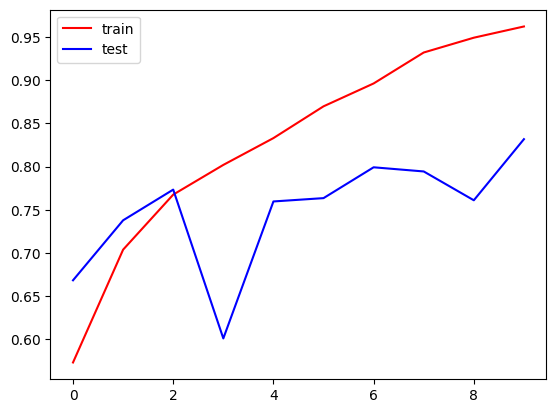

In [ ]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='test')
plt.legend()
plt.show()

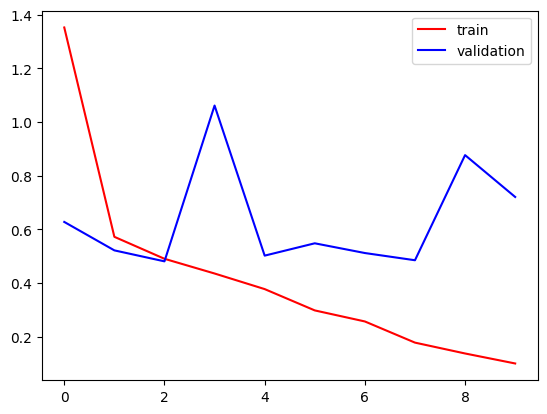

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
# Testing this model from a custom unseen data. I downloaded these from google)
import cv2
test_img1 = cv2.imread("/OIP.jpg")
test_img2 = cv2.imread("/pexels-ryan-leeper-16179805.jpg")

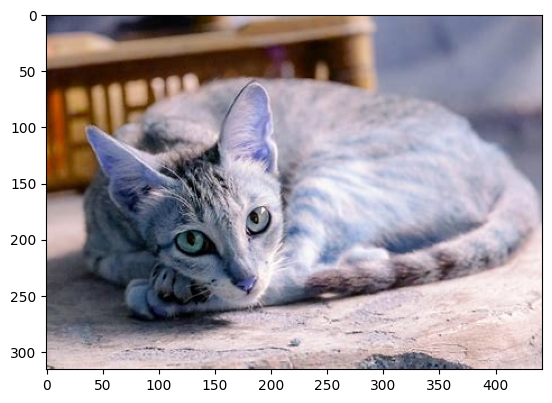

In [ ]:
plt.imshow(test_img1)

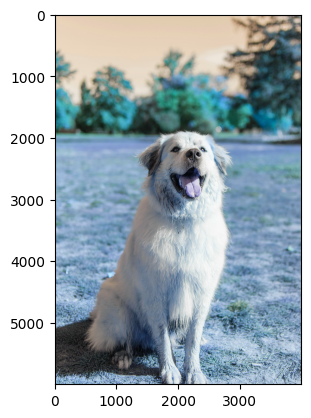

In [ ]:
plt.imshow(test_img2)

In [ ]:
test_img1.shape

(316, 442, 3)

In [ ]:
test_img1 = cv2.resize(test_img1, (256,256))
test_input1 = test_img1.reshape((1,256,256,3))

In [ ]:
test_img2.shape

(6000, 4000, 3)

In [ ]:
test_img2 = cv2.resize(test_img2, (256,256))
test_input2 = test_img2.reshape((1,256,256,3))

In [ ]:
 # 0 means cat and 1 means dog for our classifier since it's binary classifier

In [ ]:
model.predict(test_input1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.]], dtype=float32)

In [ ]:
model.predict(test_input2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[0.]], dtype=float32)

In [ ]:
# The model is purely overfitting. Even though it's a dog image, it still classifies it as a cat image

# Now applying Data augmentation

In [ ]:
 import kagglehub

# Download latest version
path = kagglehub.dataset_download("moazeldsokyx/dogs-vs-cats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogs-vs-cats' dataset.
Path to dataset files: /kaggle/input/dogs-vs-cats


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size = 16

# this is the augmentation configuration that we will use for training
train_datagen = ImageDataGenerator(
    rescale= 1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip = True
)

# Augmentation configuration that we will use for training
test_datagen = ImageDataGenerator(rescale=1./255)
# we are only rescaling in test data because we dont want data in test dataset.
# we will use that for prediction. WE need data in training not test.

# This is a generator that will read pictures found in the subfolders
# batches of augmented image data
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/dogs-vs-cats/dataset/train',
    target_size=(150,150),
    batch_size=batch_size,
    class_mode='binary' # since we are using binary_crossentropy
)

# This is a similar generator for validation data
validation_generator = test_datagen.flow_from_directory(
    '/kaggle/input/dogs-vs-cats/dataset/test',
    target_size=(150,150),
    batch_size=batch_size,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 12461 images belonging to 2 classes.


In [ ]:
# We will apply dropout and Batch Norm
from keras.layers import BatchNormalization, Dropout
# creating the CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_generator,epochs=10, validation_data=validation_generator, steps_per_epoch=2000//batch_size, validation_steps=800//batch_size)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5505 - loss: 2.1904

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 162ms/step - accuracy: 0.5505 - loss: 2.1869 - val_accuracy: 0.5663 - val_loss: 1.3150
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.5705 - loss: 0.9711 - val_accuracy: 0.5738 - val_loss: 0.7795
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.5769 - loss: 0.7679 - val_accuracy: 0.6150 - val_loss: 0.7521
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.6499 - loss: 0.6520 - val_accuracy: 0.6363 - val_loss: 0.6255
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - accuracy: 0.6686 - loss: 0.6240 - val_accuracy: 0.5750 - val_loss: 0.8024
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.6775 - loss: 0.5919 - val_accuracy: 0.6913 - val_loss: 0.5877
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.6751 - loss: 0.5906 - val_accuracy: 0.5638 - val_loss: 0.9732
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.6770 - loss: 0.5752 - val

In [ ]:
import matplotlib.pyplot as plt

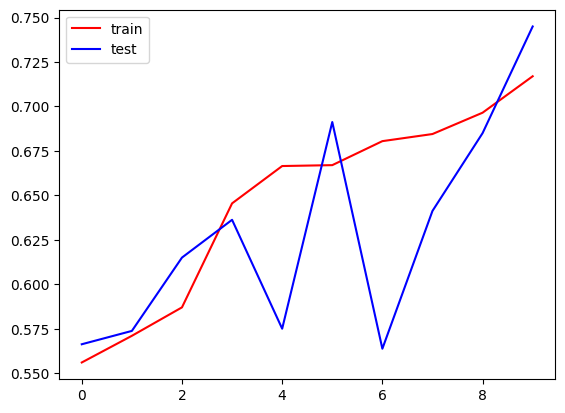

In [ ]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='test')
plt.legend()
plt.show()

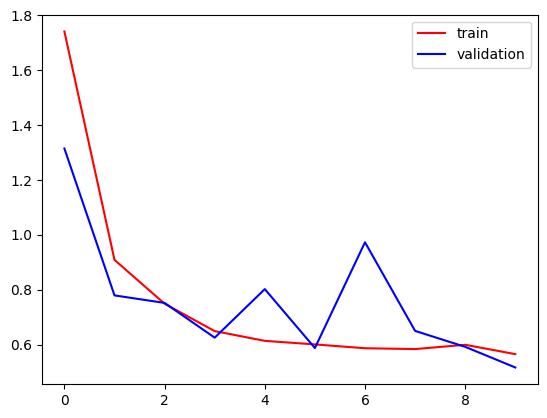

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
# Testing this model from a custom unseen data. I downloaded these from google)
import cv2
test_img1 = cv2.imread("/OIP.jpg")
test_img2 = cv2.imread("/pexels-ryan-leeper-16179805.jpg")

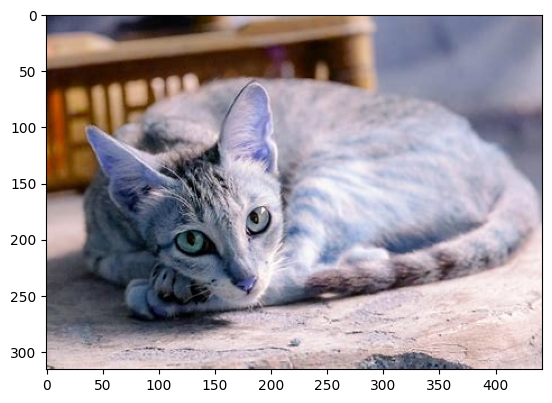

In [ ]:
plt.imshow(test_img1)

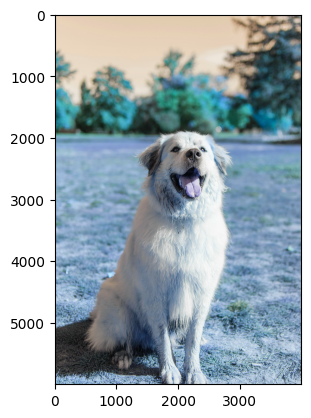

In [ ]:
plt.imshow(test_img2)

In [ ]:
test_img1.shape

(316, 442, 3)

In [ ]:
test_img1 = cv2.resize(test_img1, (256,256))
test_input1 = test_img1.reshape((1,256,256,3))

In [ ]:
test_img2.shape

(6000, 4000, 3)

In [ ]:
test_img2 = cv2.resize(test_img2, (256,256))
test_input2 = test_img2.reshape((1,256,256,3))

In [ ]:
 # 0 means cat and 1 means dog for our classifier since it's binary classifier

In [ ]:
model.predict(test_input1)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_3" is incompatible with the layer: expected axis -1 of input shape to have value 36992, but received input with shape (1, 115200)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 256, 256, 3), dtype=uint8)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
model.predict(test_input2)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_3" is incompatible with the layer: expected axis -1 of input shape to have value 36992, but received input with shape (1, 115200)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 256, 256, 3), dtype=uint8)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

# Getting help from gemini :)

## Adjust test image resizing

### Subtask:
Resize `test_img1` and `test_img2` to (150, 150) to match the input size used during model training.


**Reasoning**:
To match the input size used during model training, I need to resize both `test_img1` and `test_img2` to `(150, 150)` and then reshape them to `(1, 150, 150, 3)` to prepare them for prediction.



In [ ]:
test_img1 = cv2.resize(test_img1, (150,150))
test_input1 = test_img1.reshape((1,150,150,3))
test_img2 = cv2.resize(test_img2, (150,150))
test_input2 = test_img2.reshape((1,150,150,3))
print("Resized test_img1 shape:", test_input1.shape)
print("Resized test_img2 shape:", test_input2.shape)

Resized test_img1 shape: (1, 150, 150, 3)
Resized test_img2 shape: (1, 150, 150, 3)


## Predict with corrected inputs

### Subtask:
Execute the `model.predict` calls for both `test_input1` and `test_input2` to get the predictions with the correct input size.


**Reasoning**:
Execute the model.predict calls for `test_input1` to obtain the prediction after correcting the input size.



In [ ]:
prediction1 = model.predict(test_input1)
print("Prediction for test_input1:", prediction1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
Prediction for test_input1: [[1.]]


**Reasoning**:
Execute the model.predict calls for `test_input2` to obtain the prediction after correcting the input size.



In [ ]:
prediction2 = model.predict(test_input2)
print("Prediction for test_input2:", prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction for test_input2: [[1.]]


## Final Task

### Subtask:
Confirm if the prediction issue is resolved and interpret the model's predictions on the custom test images.


## Summary:

### Q&A
*   **Is the prediction issue resolved?**
    Yes, the prediction issue related to incorrect input size has been resolved. After resizing `test_img1` and `test_img2` to `(150, 150)` and reshaping them to `(1, 150, 150, 3)`, the model successfully generated predictions without errors.
*   **How to interpret the model's predictions on the custom test images?**
    For both `test_input1` and `test_input2`, the model predicted `[[1.]]`. Without further context on what the model's output `1.0` represents (e.g., a specific class in a binary or multi-class classification), a detailed interpretation is limited to stating the numerical output.

### Data Analysis Key Findings
*   `test_img1` and `test_img2` were successfully resized to `(150, 150)` and reshaped to `(1, 150, 150, 3)` to match the model's expected input shape.
*   The model successfully generated predictions for both `test_input1` and `test_input2` after the input resizing and reshaping.
*   Both `test_input1` and `test_input2` resulted in an identical prediction of `[[1.]]`.

### Insights or Next Steps
*   The successful execution of predictions after resizing confirms that the input shape mismatch was the root cause of any previous prediction issues.
*   To fully interpret the meaning of the `[[1.]]` prediction, the model's class labels or output mapping needs to be examined.
